In [ ]:
import scanpy as sc
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
%load_ext autoreload
%autoreload 2

from gfm import GFM
from gfm.helpers import get_pert_graph_info, add_pert_graph_metrics, combine_results

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 8

## combined all datasets

In [ ]:
result_list = []
pert_adata_path="../data/preprocessed_replogle_2022_k562_gwps.h5ad"
for dataset in  ['replogle_k562', 'replogle_rpe1', 'nadig_jurkat', 'nadig_hepg2']:
    adata = sc.read_h5ad(f"../data/preprocessed_{dataset}.h5ad")

    for split in [1, 2, 3]:
        split_path = f"../data/splits/{dataset}_single_{split}_0.75.pkl"
        gfm = GFM(
            adata=adata,
            split_dict_path=split_path,
            output_dir=f"../data/gfm/{dataset}/split_{split}/",
            device=device
        )
        gfm.initialize_fm(graph_type="go+pert+ppi", pert_encoding="gat", pert_adata_path=pert_adata_path)
        result_dict = {
            'GFM': [f"../data/gfm/{dataset}/split_{split}/results_test_gfm_go+gwps+ppi_gat.csv"],
            'Perturb train': [f"../data/pert_train/{dataset}/results_test_{split}.csv"]
        }
        result_combined = combine_results(result_dict, baseline_model="Perturb train")
        pert_graph_info = get_pert_graph_info(gfm, gfm.split.split_dict['test'])
        add_pert_graph_metrics(result_combined, pert_graph_info)
        result_combined['split'] = split
        result_combined['dataset'] = dataset
        result_list.append(result_combined)

result_all = pd.concat(result_list, ignore_index=True)

In [ ]:
result_all.head()

,mse,pearson,spearman,mmd,pearson_delta,w2d,e_distance,condition,split,model,n_source_nodes_trained,train_node_ratio,max_sim,median_sim,dataset
0,-0.048766,-0.007478,0.000000,0.156272,0.090054,-0.434850,0.501423,MRPS14+ctrl,1,GFM,126,0.215017,0.577982,0.258496,replogle_k562
1,-0.175831,0.044111,0.018045,0.103384,0.719255,-0.875378,-0.355630,EIF3M+ctrl,1,GFM,208,0.316109,0.726302,0.306558,replogle_k562
2,-0.135953,0.059218,0.079699,0.064929,0.954350,-0.732856,-0.227182,SNAPC3+ctrl,1,GFM,239,0.331025,0.630097,0.125640,replogle_k562
3,-0.029846,0.005016,0.003008,0.056765,0.859069,-0.663936,-0.094224,ELP5+ctrl,1,GFM,171,0.183476,0.455992,0.138405,replogle_k562
4,-0.039252,-0.002429,0.022556,0.025218,0.959807,-0.457822,0.006299,POLA1+ctrl,1,GFM,104,0.246445,0.868944,0.359768,replogle_k562


In [ ]:
result_all.to_csv(f"../data/final_plots_data/correlation_dotplot_graph_metrics_new.csv", index=False)

In [ ]:
result_all = pd.read_csv(f"../data/final_plots_data/correlation_dotplot_graph_metrics_new.csv")

In [ ]:
from scipy.stats import spearmanr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x_cols = ['n_source_nodes_trained', 'train_node_ratio', 'max_sim', 'median_sim']
y_cols = ['mse', 'pearson', 'pearson_delta', 'w2d', 'e_distance']

x_labels = {
    'n_source_nodes_trained': 'Train neighbors',
    'train_node_ratio': 'Train-neighbor fraction',
    'max_sim': 'Max similarity',
    'median_sim': 'Median similarity',
}

y_labels = {
        'mse': 'Δ MSE',
        'pearson': 'Δ Pearson',
        'pearson_delta': 'Pearson Delta',
        'spearman': 'Δ Spearman',
        'mmd': 'Δ MMD',
        'w2d': 'Δ 2-WD',
        'e_distance': 'Δ E-Distance'
    }

def fisher_mean(rhos):
    rhos = np.asarray(rhos)
    rhos = np.clip(rhos, -0.999999, 0.999999)
    return np.tanh(np.mean(np.arctanh(rhos)))

In [ ]:
corr_rows = []

for (dataset, split), group in result_all.groupby(['dataset', 'split']):
    for x_col in x_cols:
        for y_col in y_cols:
            valid = group[[x_col, y_col]].dropna()

            if len(valid) < 3:
                continue

            rho, p_value = spearmanr(valid[x_col], valid[y_col])

            corr_rows.append({
                'dataset': dataset,
                'split': split,
                'x_col': x_col,
                'y_col': y_col,
                'rho': rho,
                'p_value': p_value,
            })

corr_by_split = pd.DataFrame(corr_rows)

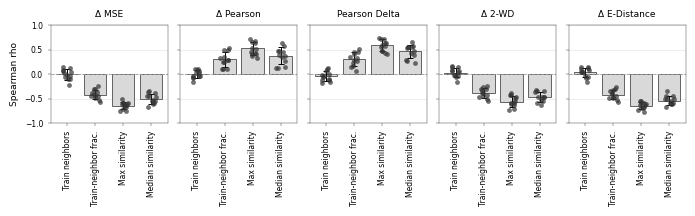

In [ ]:
summary = (
    corr_by_split
    .groupby(['y_col', 'x_col'])
    .agg(
        mean_rho=('rho', fisher_mean),
        sd_rho=('rho', 'std'),
        n=('rho', 'size'),
    )
    .reset_index()
)
summary['sd_rho'] = summary['sd_rho'].fillna(0)

fig, axes = plt.subplots(1, len(y_cols), figsize=(1.4 * len(y_cols), 2.2), sharey=True)
if len(y_cols) == 1:
    axes = [axes]

for ax, y_col in zip(axes, y_cols):
    stats = (
        summary[summary['y_col'] == y_col]
        .set_index('x_col')
        .reindex(x_cols)
        .reset_index()
    )

    subset = corr_by_split[corr_by_split['y_col'] == y_col].copy()
    subset = subset.dropna(subset=['rho', 'x_col'])

    x_positions = np.arange(len(x_cols))

    means = stats['mean_rho'].to_numpy(dtype=float)
    errs = stats['sd_rho'].to_numpy(dtype=float)

    ax.bar(
        x_positions,
        means,
        yerr=errs,
        color='0.85',
        edgecolor='0.3',
        linewidth=0.6,
        error_kw={'elinewidth': 0.7, 'capsize': 2, 'capthick': 0.7},
        zorder=2,
    )

    rng = np.random.default_rng(42)
    x_map = {name: i for i, name in enumerate(x_cols)}
    subset['x_base'] = subset['x_col'].map(x_map).astype(float)
    subset['x_jitter'] = subset['x_base'] + rng.uniform(-0.18, 0.18, len(subset))

    ax.scatter(
        subset['x_jitter'],
        subset['rho'],
        color='0.2',
        s=12,
        alpha=0.7,
        linewidth=0,
        zorder=3,
    )

    ax.axhline(0, color='0.6', linestyle='--', linewidth=0.6)
    ax.set_title(y_labels[y_col])
    ax.set_ylim(-1.0, 1.0)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([x_labels[x] for x in x_cols], rotation=90)
    ax.grid(axis='y', alpha=0.2)
    # ax.tick_params(axis='y', labelleft=True, left=False)

axes[0].set_ylabel('Spearman rho')
for ax in axes[1:]:
    ax.set_ylabel('')

# fig.suptitle('Graph Connectivity vs Prediction Performance', y=1.04)
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.savefig('../data/final_plots/correlation_barplot_graph_metrics_new.pdf', dpi=300, bbox_inches='tight')
plt.show()